# Romanian Idiom Embeddings – Dissertation Notebook

## 1. Data preprocessing

In [1]:
import pandas as pd
import re

# load dataset
df = pd.read_excel("romanian_idioms_dataset.xlsx")
df.head()

# lowercase
df["expression"] = df["expression"].str.lower()
df["context_sentence"] = df["context_sentence"].str.lower()

# remove punctuation
def clean_text(text):
    text = text.replace("-", " ")
    return re.sub(r"[^\w\săâîșț]", "", text)

df["expression_clean"] = df["expression"].apply(clean_text)

# tokenize
df["tokens"] = df["expression_clean"].apply(lambda x: x.split())

# number of tokens
df["length"] = df["tokens"].apply(len)

print(df.head())

    id            expression                  figurative_meaning    tip  \
0  1.0  a da cu bâta-n baltă  a face o gafă; a strica o situație  idiom   
1  2.0     a bate apa-n piuă       a repeta inutil același lucru  idiom   
2  3.0         a freca menta         a pierde vremea; a trândăvi  idiom   
3  4.0    a pune paie pe foc                a agrava un conflict  idiom   
4  5.0    a o lua pe arătură    a devia de la subiect; a exagera  idiom   

  opacity                                   context_sentence  \
0       4  în ședință, a dat cu bâta-n baltă și a supărat...   
1       4    de o oră bate apa-n piuă și nu spune nimic nou.   
2       5  în loc să freci menta, mai bine termini raportul.   
3       3  comentariul lui a pus paie pe foc într-o discu...   
4       4  când a început cu teoriile lui, a luat-o pe ar...   

       expression_clean                       tokens  length  
0  a da cu bâta n baltă  [a, da, cu, bâta, n, baltă]       6  
1     a bate apa n piuă      [a, bate,

2. Exploratory data analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# load dataset
df = pd.read_excel("romanian_idioms_dataset.xlsx")

# basic cleaning
df["expression"] = df["expression"].astype(str).str.strip().str.lower()
df["context_sentence"] = df["context_sentence"].astype(str).str.strip().str.lower()

# helper for tokenization
def clean_text(text):
    text = text.replace("-", " ")
    return re.sub(r"[^\w\săâîșț]", "", text)

# preprocess expressions
df["expression_clean"] = df["expression"].apply(clean_text)
df["expression_tokens"] = df["expression_clean"].apply(lambda x: x.split())
df["expression_length"] = df["expression_tokens"].apply(len)

# preprocess context sentences
df["context_clean"] = df["context_sentence"].apply(clean_text)
df["context_tokens"] = df["context_clean"].apply(lambda x: x.split())
df["context_length"] = df["context_tokens"].apply(len)

# dataset overview
print("Number of idioms:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# convert opacity to numeric
df["opacity"] = pd.to_numeric(df["opacity"], errors="coerce")

print("\nOpacity distribution:")
print(df["opacity"].value_counts().sort_index())

print("\nExpression length stats:")
print(df["expression_length"].describe())

print("\nContext length stats:")
print(df["context_length"].describe())

Number of idioms: 330

Columns:
['id', 'expression', 'figurative_meaning', 'tip', 'opacity', 'context_sentence', 'expression_clean', 'expression_tokens', 'expression_length', 'context_clean', 'context_tokens', 'context_length']

Missing values:
id                    0
expression            0
figurative_meaning    0
tip                   0
opacity               0
context_sentence      0
expression_clean      0
expression_tokens     0
expression_length     0
context_clean         0
context_tokens        0
context_length        0
dtype: int64

Opacity distribution:
opacity
1.0     23
2.0     64
3.0     93
4.0    101
5.0     48
Name: count, dtype: int64

Expression length stats:
count    330.000000
mean       4.821212
std        1.133158
min        3.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        9.000000
Name: expression_length, dtype: float64

Context length stats:
count    330.000000
mean       8.427273
std        1.768308
min        1.000000
25%        7.

## 3. Sentence Transformer

In [3]:
!pip install -q sentence-transformers scikit-learn openpyxl

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



## 4. Embedding extraction. Cosine similarity computation

In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

expression_similarities = []

for _, row in df.iterrows():
    expression = row["expression"]
    tokens = row["expression_tokens"]

    # embedding pentru expresia completă
    expr_emb = model.encode([expression])[0]

    # embeddings pentru fiecare cuvânt
    token_embs = model.encode(tokens)

    # media embeddingurilor componentelor
    mean_token_emb = np.mean(token_embs, axis=0)

    # cosine similarity
    sim = cosine_similarity(
        expr_emb.reshape(1, -1),
        mean_token_emb.reshape(1, -1)
    )[0][0]

    expression_similarities.append(sim)

df["cosine_similarity"] = expression_similarities
df[["expression", "opacity", "cosine_similarity"]].head(10)

,expression,opacity,cosine_similarity
0,a da cu bâta-n baltă,4.0,0.660791
1,a bate apa-n piuă,4.0,0.568646
2,a freca menta,5.0,0.819780
3,a pune paie pe foc,3.0,0.672380
4,a o lua pe arătură,4.0,0.680738
5,a tăia frunză la câini,5.0,0.510551
6,a se face de râs,2.0,0.614392
7,a lua taurul de coarne,3.0,0.673817
8,a călca pe bec,4.0,0.599748
9,a da bir cu fugiții,4.0,0.656567


In [6]:
df.to_csv("idioms_with_similarity.csv", index=False)
from google.colab import files
files.download("idioms_with_similarity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
df.groupby("opacity")["cosine_similarity"].mean()

,cosine_similarity
opacity,
1.0,0.677167
2.0,0.687734
3.0,0.678703
4.0,0.671988
5.0,0.668968


5. Results

The average cosine similarity between the embedding of the full idiomatic expression and the mean embedding of its component words was computed for each opacity level. The results show relatively small differences across opacity categories.

Opacity	Average cosine similarity
1	0.677
2	0.688
3	0.679
4	0.672
5	0.669

Although slightly lower similarity values appear for higher opacity levels, the differences are minimal. This suggests that the multilingual sentence-transformer model does not strongly differentiate between more compositional and more opaque idiomatic expressions.

Corellation

In [8]:
df["opacity"].corr(df["cosine_similarity"], method="pearson")

np.float64(-0.05053732979396754)

6. Correlation Analysis

To further investigate the relationship between idiom opacity and compositional similarity, the Pearson correlation coefficient was computed between the opacity scores and the cosine similarity values obtained from the embedding comparison.

The resulting correlation coefficient was:

𝑟
=
−
0.05
r=−0.05

This value indicates a very weak negative correlation between idiom opacity and compositional similarity. Although the negative sign suggests a tendency for more opaque idioms to exhibit slightly lower similarity between the full-expression embedding and the averaged component embeddings, the strength of this relationship is minimal.

These results suggest that the multilingual sentence-transformer model does not strongly capture the semantic non-compositionality associated with idiomatic expressions.

In [9]:
df["opacity"].corr(df["cosine_similarity"], method="spearman")

np.float64(-0.05296864345758066)


## 7. Visualization of results

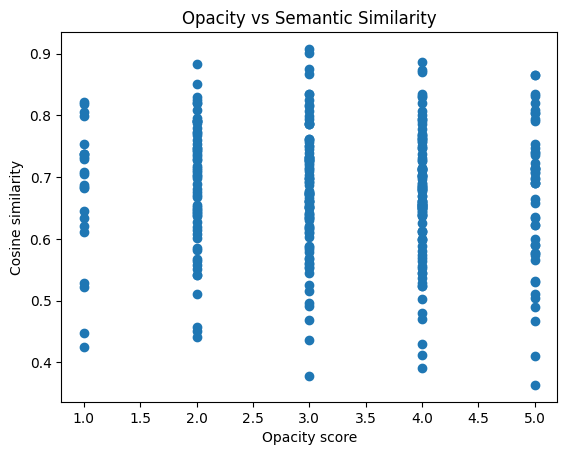

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["opacity"], df["cosine_similarity"])
plt.xlabel("Opacity score")
plt.ylabel("Cosine similarity")
plt.title("Opacity vs Semantic Similarity")
plt.show()

Relationship Between Opacity and Semantic Similarity

Figure X illustrates the relationship between idiom opacity and cosine similarity between the embedding of the full idiomatic expression and the averaged embeddings of its component words.

The scatter plot shows a wide dispersion of similarity values across all opacity levels. No strong decreasing trend can be observed as opacity increases.

This observation is consistent with the computed Pearson correlation coefficient (r = -0.05), which indicates only a very weak negative relationship between opacity and compositional similarity.

These findings suggest that the multilingual sentence-transformer model does not strongly capture the semantic non-compositionality associated with idiomatic expressions.